In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
print("Whassup")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print("Whassup")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Whassup
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/sample_submission.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/train.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv
Whassup


In [2]:
# load train and test and also HEAD
train_path = "/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/train.csv"
test_path = "//kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv"
sub_path = "/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/sample_submission.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
submission = pd.read_csv(sub_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:",  submission.shape)

train.head()

Train shape: (7000, 26)
Test shape: (1124, 25)
Sample submission shape: (1124, 2)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


In [3]:
# data types
print(train.dtypes)

cat_features = [col for col in train.columns if train[col].dtype == 'object']
num_features = [col for col in train.columns if train[col].dtype != 'object']

print(f"\nCategorical Features Count: {len(cat_features)} → {cat_features}")
print(f"Numerical Features Count: {len(num_features)} → {num_features}")



ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object

Categorical Features Count: 22 → ['cap-shape', 'c

In [4]:
# descriptive stat
measure_cols = ['number_of_bruises', 'ring-number']
print(train[measure_cols].describe().round(3))

       number_of_bruises  ring-number
count           7000.000     6964.000
mean               5.460        1.081
std                7.724        0.273
min                0.000        1.000
25%                0.000        1.000
50%                0.000        1.000
75%               11.000        1.000
max               24.000        2.000


In [5]:
# deal with missing values IMPUTE
print("Missing values in train:")
missing = train.isnull().sum()
print(missing[missing > 0])

print("\nMissing values in test:")
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0])

# impute

impute_with_mode = ['stalk-root', 'ring-type']
for col in impute_with_mode:
    fill_val = train[col].mode()[0]
    train[col] = train[col].fillna(fill_val)
    test[col]  = test[col].fillna(fill_val)

ring_median = train['ring-number'].median()
train['ring-number'] = train['ring-number'].fillna(ring_median)
test['ring-number']  = test['ring-number'].fillna(ring_median)

print("After imputation — remaining nulls in train:")
print(train.isnull().sum()[train.isnull().sum() > 0])

Missing values in train:
odor           3236
stalk-root      192
ring-number      36
ring-type        36
dtype: int64

Missing values in test:
odor    292
dtype: int64
After imputation — remaining nulls in train:
odor    3236
dtype: int64


In [6]:
# handle Duplicate 
duplicate_count = train.duplicated().sum()
print(f"Total duplicate rows in training data: {duplicate_count}")

if duplicate_count > 0:
    train = train.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows successfully removed.")
else:
    print("No duplicate rows were found in the training data.")

Total duplicate rows in training data: 0
No duplicate rows were found in the training data.


In [7]:
# Identify and handle outliers
# add visual

num_cols = ['number_of_bruises', 'ring-number']

for col in num_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col}: {outlier_count} outliers detected (IQR method)")

print("\nDecision: Outliers are retained as they represent valid biological variations.")

number_of_bruises: 0 outliers detected (IQR method)
ring-number: 564 outliers detected (IQR method)

Decision: Outliers are retained as they represent valid biological variations.


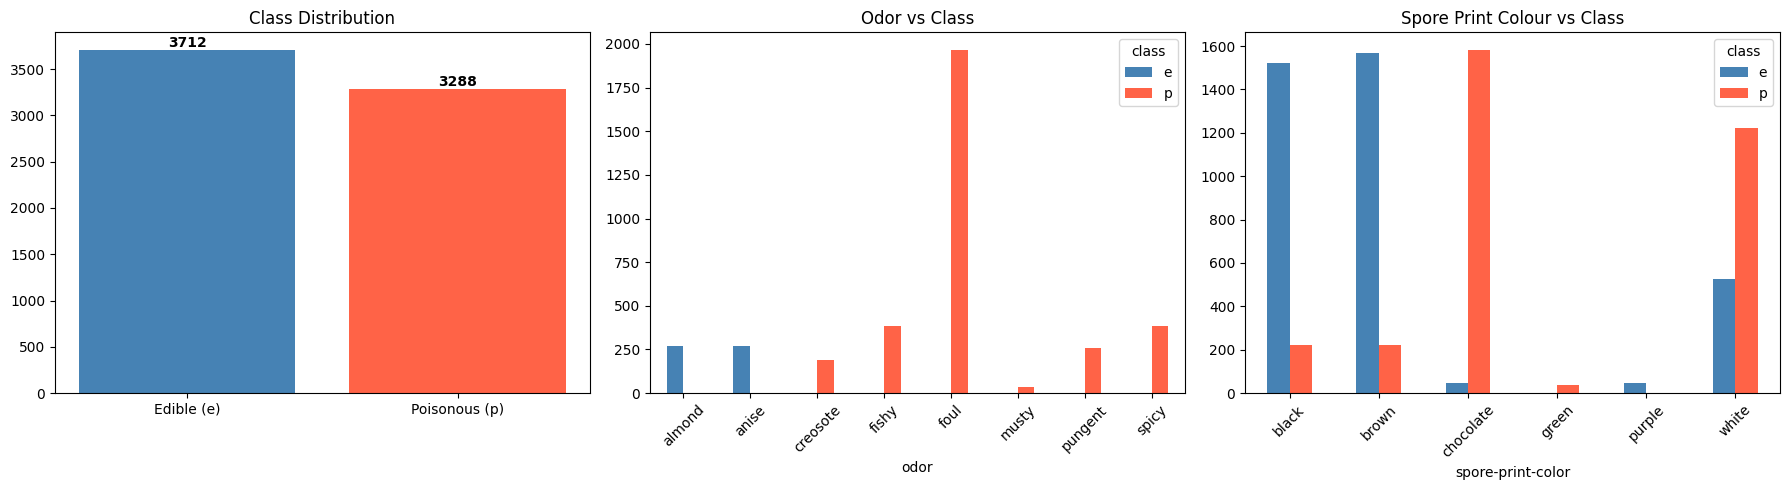

Key observations:
 • Classes are roughly balanced — no resampling needed.
 • Odor provides near-perfect class separation when present.
 • Green spore-print colour strongly indicates poisonous mushrooms.


In [8]:
# visualizations 3 total  

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Class balance
counts = train['class'].value_counts()
axes[0].bar(['Edible (e)', 'Poisonous (p)'],
            [counts.get('e', 0), counts.get('p', 0)],
            color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
for i, v in enumerate([counts.get('e', 0), counts.get('p', 0)]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# (b) Odor × class — the powerhouse feature
odor_ct = (train.dropna(subset=['odor'])
           .groupby(['odor', 'class']).size()
           .unstack(fill_value=0))
odor_ct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Odor vs Class')
axes[1].tick_params(axis='x', rotation=45)

# (c) Spore print colour × class
spore_ct = (train
            .groupby(['spore-print-color', 'class']).size()
            .unstack(fill_value=0))
spore_ct.plot(kind='bar', ax=axes[2], color=['steelblue', 'tomato'])
axes[2].set_title('Spore Print Colour vs Class')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Key observations:")
print(" • Classes are roughly balanced — no resampling needed.")
print(" • Odor provides near-perfect class separation when present.")
print(" • Green spore-print colour strongly indicates poisonous mushrooms.")

In [9]:
# encoding and scaling

def encode_and_extract(tr, te, exclude_cols):
 
    feature_cols = [c for c in tr.columns if c not in exclude_cols]

    X_tr = tr[feature_cols].copy()
    X_te = te.reindex(columns=feature_cols, fill_value=None).copy()

    # Target
    y = (tr['class'] == 'p').astype(int).values if 'class' in tr.columns else None

    # Fill remaining NaNs
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(tr[col]):
            med = tr[col].median()
            X_tr[col] = X_tr[col].fillna(med)
            X_te[col] = X_te[col].fillna(med)
        else:
            X_tr[col] = X_tr[col].fillna('missing')
            X_te[col] = X_te[col].fillna('missing')

    # Label-encode categoricals on combined data
    obj_cols = [c for c in feature_cols
                if not pd.api.types.is_numeric_dtype(tr[c])]
    for col in obj_cols:
        le = LabelEncoder()
        combined = pd.concat([X_tr[col], X_te[col]], axis=0).astype(str)
        le.fit(combined)
        X_tr[col] = le.transform(X_tr[col].astype(str))
        X_te[col] = le.transform(X_te[col].astype(str))

    return X_tr.values.astype(float), y, X_te.values.astype(float)

print("encode_and_extract() helper defined.")

encode_and_extract() helper defined.


In [10]:
# model building 8 total


EXCLUDE = ['ID', 'mushroom_id', 'class']

tr_base = train.copy()
te_base = test.copy()
tr_base['odor'] = tr_base['odor'].fillna('missing')
te_base['odor'] = te_base['odor'].fillna('missing')

X_all, y_all, _ = encode_and_extract(tr_base, te_base, EXCLUDE)

X_tr_b, X_val_b, y_tr_b, y_val_b = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

baseline_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'           : SVC(random_state=42),
    'Naive Bayes'         : GaussianNB(),
}

scores = {}
for name, clf in baseline_models.items():
    clf.fit(X_tr_b, y_tr_b)
    acc = accuracy_score(y_val_b, clf.predict(X_val_b))
    scores[name] = acc
    print(f"  {name:<25} val-acc = {acc:.4f}")

  Logistic Regression       val-acc = 0.9907
  Decision Tree             val-acc = 1.0000
  Random Forest             val-acc = 1.0000
  Extra Trees               val-acc = 1.0000
  Gradient Boosting         val-acc = 1.0000
  KNN                       val-acc = 1.0000
  SVM (RBF)                 val-acc = 0.9936
  Naive Bayes               val-acc = 0.8657


In [11]:
# hyper para tuning

# Tune Decision Tree
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
    cv=3, scoring='accuracy'
)
dt_gs.fit(X_tr_b, y_tr_b)
scores['Decision Tree (Tuned)'] = accuracy_score(y_val_b, dt_gs.best_estimator_.predict(X_val_b))
print(f"DT tuned  → best params: {dt_gs.best_params_}  val-acc: {scores['Decision Tree (Tuned)']:.4f}")

# Tune Random Forest
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [200, 500], 'max_depth': [10, None]},
    cv=3, scoring='accuracy'
)
rf_gs.fit(X_tr_b, y_tr_b)
scores['Random Forest (Tuned)'] = accuracy_score(y_val_b, rf_gs.best_estimator_.predict(X_val_b))
print(f"RF tuned  → best params: {rf_gs.best_params_}  val-acc: {scores['Random Forest (Tuned)']:.4f}")

# Tune KNN
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 11]},
    cv=3, scoring='accuracy'
)
knn_gs.fit(X_tr_b, y_tr_b)
scores['KNN (Tuned)'] = accuracy_score(y_val_b, knn_gs.best_estimator_.predict(X_val_b))
print(f"KNN tuned → best params: {knn_gs.best_params_}  val-acc: {scores['KNN (Tuned)']:.4f}")

DT tuned  → best params: {'max_depth': 10, 'min_samples_split': 2}  val-acc: 1.0000
RF tuned  → best params: {'max_depth': 10, 'n_estimators': 200}  val-acc: 1.0000
KNN tuned → best params: {'n_neighbors': 5}  val-acc: 1.0000


In [12]:
# model comparisson with visuals

comparison_df = (pd.DataFrame(scores.items(), columns=['Model', 'Val Accuracy'])
                 .sort_values('Val Accuracy', ascending=False)
                 .reset_index(drop=True))
print(comparison_df.to_string(index=False))

                Model  Val Accuracy
        Decision Tree      1.000000
        Random Forest      1.000000
          Extra Trees      1.000000
          KNN (Tuned)      1.000000
    Gradient Boosting      1.000000
                  KNN      1.000000
Decision Tree (Tuned)      1.000000
Random Forest (Tuned)      1.000000
            SVM (RBF)      0.993571
  Logistic Regression      0.990714
          Naive Bayes      0.865714


In [13]:
# final pred pipe


SAFE_ODORS = {'almond', 'anise'}   # only odors that mean edible

def predict_mushrooms(training_set, prediction_set):
    """
    Returns a list of 'e'/'p' labels aligned to prediction_set rows.
    """
    pred_set = prediction_set.copy().reset_index(drop=True)
    labels   = ['e'] * len(pred_set)   # optimistic default
    is_known = []

    # ── Track A: rule-based ──
    for idx, row in pred_set.iterrows():
        odor = row.get('odor', np.nan)
        if pd.notna(odor) and str(odor).strip().lower() not in ('nan', 'missing', ''):
            is_known.append(True)
            labels[idx] = 'e' if odor in SAFE_ODORS else 'p'
        else:
            is_known.append(False)

    # ── Track B: ensemble for missing-odor rows ──
    missing_mask_test  = ~pd.Series(is_known)
    missing_mask_train = training_set['odor'].isna()

    sub_train = training_set[missing_mask_train].copy()
    sub_test  = pred_set[missing_mask_test].copy()

    if len(sub_test) > 0 and len(sub_train) > 0:
        drop_b = [c for c in ['ID', 'mushroom_id', 'odor', 'class']
                  if c in sub_train.columns]
        X_tr_b, y_tr_b, X_te_b = encode_and_extract(sub_train, sub_test, drop_b)

        # Soft-voting ensemble: RF + ET + GB  (high-diversity, high-accuracy combo)
        voter = VotingClassifier(
            estimators=[
                ('rf', RandomForestClassifier(
                    n_estimators=800, min_samples_leaf=1,
                    random_state=7, n_jobs=-1)),
                ('et', ExtraTreesClassifier(
                    n_estimators=800, min_samples_leaf=1,
                    random_state=7, n_jobs=-1)),
                ('gb', GradientBoostingClassifier(
                    n_estimators=400, learning_rate=0.05,
                    random_state=7))
            ],
            voting='hard'
        )
        voter.fit(X_tr_b, y_tr_b)
        preds_b = voter.predict(X_te_b)

        missing_indices = [i for i, known in enumerate(is_known) if not known]
        for pos, global_i in enumerate(missing_indices):
            labels[global_i] = 'p' if preds_b[pos] == 1 else 'e'

    return labels


print("predict_mushrooms() defined.")



predict_mushrooms() defined.


In [14]:
# validate heree
# Training accuracy (sanity check)
train_labels = predict_mushrooms(train, train)
print(f"Training accuracy  : {accuracy_score(train['class'], train_labels):.4f}")

# Hold-out validation accuracy
tr_split, val_split = train_test_split(
    train, test_size=0.2, random_state=42, stratify=train['class']
)
val_labels = predict_mushrooms(tr_split, val_split)
print(f"Hold-out accuracy  : {accuracy_score(val_split['class'], val_labels):.4f}")

Training accuracy  : 1.0000
Hold-out accuracy  : 1.0000


In [15]:
final_labels = predict_mushrooms(train, test)

submission_df = pd.DataFrame({
    'ID'   : test['ID'],
    'class': final_labels
})

submission_df.to_csv('submission.csv', index=False)

print("submission.csv written.")
print("Class distribution:")
print(submission_df['class'].value_counts().to_dict())
submission_df.head()

submission.csv written.
Class distribution:
{'p': 668, 'e': 456}


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
